In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("LỰA CHỌN A: ẢNH")


LỰA CHỌN A: ẢNH


In [2]:
danh_sach_anh = [
    "photo1.jpg", "photo2.jpg", "photo3.jpg", "photo4.jpg",
    "photo5.jpg", "photo6.jpg", "photo7.jpg", "photo8.jpg"
]
kich_thuoc_chuan = (500, 500)
du_lieu_anh = []

for ten_file in danh_sach_anh:
    try:
        img = Image.open(ten_file)
        print(f"Kích thước gốc của {ten_file}: {img.size}")
        
        M = np.array(img.resize(kich_thuoc_chuan).convert("L"), dtype=float)
        du_lieu_anh.append(M.reshape(-1))
    except FileNotFoundError:
        print(f"Không tìm thấy file: {ten_file}")

X = np.array(du_lieu_anh)
print(f"\nKích thước ma trận X sau khi gộp: {X.shape}")

Kích thước gốc của photo1.jpg: (2212, 1614)
Kích thước gốc của photo2.jpg: (640, 480)
Kích thước gốc của photo3.jpg: (1920, 1005)
Kích thước gốc của photo4.jpg: (547, 365)
Kích thước gốc của photo5.jpg: (800, 450)
Kích thước gốc của photo6.jpg: (676, 295)
Kích thước gốc của photo7.jpg: (739, 415)
Kích thước gốc của photo8.jpg: (549, 364)

Kích thước ma trận X sau khi gộp: (8, 250000)


### Ý nghĩa các thông số kích thước và ma trận X

* Kích thước gốc của các ảnh

Kết quả cho thấy tám bức ảnh đầu vào có độ phân giải chiều rộng và chiều cao hoàn toàn khác nhau. Sự đa dạng về kích thước này đòi hỏi một bước tiền xử lý để ép toàn bộ hình ảnh về chung một hệ quy chiếu đồng nhất trước khi có thể xếp chung vào một ma trận toán học.

* Kích thước ma trận X sau khi gộp: (8, 250000)

Đây là cấu trúc dữ liệu thu được sau khi tất cả hình ảnh đã được chuẩn hóa về độ phân giải 500 nhân 500, chuyển đổi dải màu và duỗi phẳng. Cấu trúc ma trận hai chiều này mang ý nghĩa cụ thể như sau:

- Ý nghĩa của hàng: Giá trị 8 đại diện cho tám hàng của ma trận. Mỗi hàng đóng vai trò là một mẫu dữ liệu độc lập, chứa đựng toàn bộ các giá trị mức xám của một bức ảnh cụ thể. 

- Ý nghĩa của cột: Giá trị 250000 là kết quả phép nhân của chiều rộng và chiều cao chuẩn hóa, đại diện cho tổng số lượng điểm ảnh cấu thành nên một bức ảnh. Mỗi cột tương ứng với một đặc trưng thông tin tại một vị trí điểm ảnh cố định. Khi phân tích theo chiều dọc, hệ thống đang đối chiếu cường độ sáng của cùng một vị trí điểm ảnh xuyên suốt cả tám bức ảnh trong tập dữ liệu.

In [3]:
mean_vec = np.mean(X, axis=0)

print(f"Shape của X: {X.shape}")
print(f"Shape của mean_vec: {mean_vec.shape}")

X_centered = X - mean_vec

print(f"Shape của X_centered: {X_centered.shape}")

Shape của X: (8, 250000)
Shape của mean_vec: (250000,)
Shape của X_centered: (8, 250000)


### Giải thích kết quả phép toán cơ bản và quy tắc đồng bộ kích thước

* Kích thước ma trận gốc X: (8, 250000)


Ma trận X là cấu trúc hai chiều chứa toàn bộ dữ liệu của tám bức ảnh. Số 8 đại diện cho tám hàng, tương ứng với tám bức ảnh độc lập trong tập dữ liệu. Số 250000 đại diện cho số cột, tương ứng với tổng số điểm ảnh của mỗi bức ảnh sau khi được chuẩn hóa về mức 500 nhân 500 và duỗi phẳng.

* Kích thước vector trung bình: (250000,)


Kết quả này là một mảng một chiều chứa 250000 phần tử. Mảng này được tạo ra bằng cách tính giá trị trung bình dọc theo tám hàng cho từng cột điểm ảnh. Về bản chất, nó đại diện cho một bức ảnh trung bình được tổng hợp từ cả tám mẫu trong tập dữ liệu. Ký hiệu dấu phẩy ở cuối nhằm xác định đây là một mảng một chiều phẳng.

* Kích thước ma trận sau khi trừ: (8, 250000)


Khi thực hiện phép trừ giữa ma trận hai chiều X và mảng một chiều trung bình, hệ thống đã áp dụng quy tắc broadcasting. Mảng trung bình được tự động sao chép thành tám hàng để khớp hoàn toàn với cấu trúc của ma trận gốc, sau đó tiến hành phép trừ trên từng vị trí tương ứng. Ma trận thu được chứa các giá trị thể hiện độ chênh lệch của từng bức ảnh so với mức trung bình chung của cả nhóm, đồng thời bảo toàn nguyên vẹn kích thước ban đầu.

In [4]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

In [5]:
matrix_tuong_dong = cosine_similarity(X)

danh_sach_cap = []
so_luong = len(danh_sach_anh)

for i in range(so_luong):
    for j in range(i + 1, so_luong):
        score = matrix_tuong_dong[i, j]
        danh_sach_cap.append((score, danh_sach_anh[i], danh_sach_anh[j]))

danh_sach_cap.sort(key=lambda x: x, reverse=True)

print("TOP 3 CẶP ẢNH GIỐNG NHAU NHẤT TỔNG THỂ:")
for idx in range(3):
    score, img1, img2 = danh_sach_cap[idx]
    print(f" {idx+1}. {img1} và {img2}: Điểm tương đồng = {score:.4f}")

print("\nTOP 3 CẶP ẢNH KHÁC BIỆT NHẤT TỔNG THỂ:")
for idx in range(3):
    score, img1, img2 = danh_sach_cap[-(idx+1)]
    print(f" {idx+1}. {img1} và {img2}: Điểm tương đồng = {score:.4f}")

TOP 3 CẶP ẢNH GIỐNG NHAU NHẤT TỔNG THỂ:
 1. photo6.jpg và photo8.jpg: Điểm tương đồng = 0.9321
 2. photo7.jpg và photo8.jpg: Điểm tương đồng = 0.8971
 3. photo6.jpg và photo7.jpg: Điểm tương đồng = 0.8867

TOP 3 CẶP ẢNH KHÁC BIỆT NHẤT TỔNG THỂ:
 1. photo1.jpg và photo8.jpg: Điểm tương đồng = 0.3244
 2. photo3.jpg và photo8.jpg: Điểm tương đồng = 0.3633
 3. photo3.jpg và photo7.jpg: Điểm tương đồng = 0.3863


### Nhận xét và Đánh giá kết quả tìm kiếm tổng thể (Cosine Similarity)


* Nhóm 3 cặp ảnh giống nhau nhất (Động vật với nền sáng)
Kết quả cho thấy sự liên kết chặt chẽ giữa bộ ba: **Chim cánh cụt (`photo6`), Gấu trúc (`photo7`) và Con chồn (`photo8`)** với điểm số tương đồng rất cao (từ 0.88 đến 0.93). 
- **Giải thích:** Cả ba bức ảnh này đều chia sẻ chung một đặc điểm phân bố điểm ảnh cực kỳ tương đồng. Chúng đều có phông nền rất sáng (nền trắng tinh của con chồn, nền tuyết/nước hắt sáng của chim cánh cụt, và nền trời sáng của gấu trúc). Đồng thời, chủ thể trong ảnh đều mang họa tiết lông đen - trắng đan xen phức tạp. Khi chuyển sang ảnh xám và tính điểm Cosine, sự phân bố "nền pixel giá trị cao (sáng) bao quanh các cụm pixel giá trị thấp (tối)" của chúng hoàn toàn khớp nhau, đẩy điểm số lên mức cao nhất.

* Nhóm 3 cặp ảnh khác biệt nhất (Thiên thể nền đen vs. Động vật nền sáng)
Nhóm đối lập nhất gọi tên các cặp: **Mặt trăng (`photo1`) vs Con chồn (`photo8`); Sao thổ (`photo3`) vs Con chồn (`photo8`) / Gấu trúc (`photo7`)**. Điểm số tụt xuống mức cực thấp (chỉ từ 0.32 đến 0.38).
- **Giải thích:** Đây là sự đối lập hoàn toàn về cấu trúc không gian màu xám. Mặt trăng và Sao thổ là những khối sáng nằm gọn ở trung tâm, bao quanh bởi một phông nền không gian đen đặc (các pixel có giá trị xấp xỉ bằng 0). Trái ngược hoàn toàn, ảnh con chồn và gấu trúc lại có phông nền sáng rực và chi tiết tối lộn xộn. Sự "ngược pha" hoàn toàn về vị trí các vùng sáng/tối này khiến vector biểu diễn của chúng chỉ về hai hướng lệch nhau xa nhất trong không gian đa chiều.

* Đánh giá mức độ khớp với trực giác
Kết quả này **hoàn toàn hợp lý và khớp với nguyên lý của thị giác máy tính**. Thuật toán không hề "hiểu" nội dung bức ảnh là con vật hay hành tinh, nó chỉ đánh giá cấu trúc phân bố ánh sáng. Việc thuật toán tự động gom nhóm chính xác các ảnh "nền tối - khối sáng trung tâm" (hành tinh) ra khỏi nhóm "nền sáng - chi tiết lộn xộn" (động vật) là một minh chứng tuyệt vời cho thấy tính hiệu quả của phép đo Cosine Similarity trong việc phân cụm dữ liệu hình ảnh.

## Bài 2: Biến đổi tuyến tính & SVD

**Mục tiêu:** Hiểu ma trận như một phép biến đổi tuyến tính và sử dụng SVD (Singular Value Decomposition) để xử lý dữ liệu ảnh.

**Lựa chọn A: Ảnh**

- **3.1** Biến đổi tuyến tính: Xây ma trận quay $R(\theta)$ và ma trận co giãn $S$; áp lên tọa độ điểm và vẽ trước/sau.
- **3.2** Nén ảnh bằng SVD: Phân rã $M = U\Sigma V^{\top}$; giữ lại $k$ giá trị kỳ dị lớn nhất ($k=5, 20, 50$), tái tạo và hiển thị ảnh.
- **3.3** Đánh giá: Tính tỉ lệ nén và sai số tái tạo theo từng $k$; vẽ đồ thị.
- **3.4** Nhận xét: Với $k$ nhỏ tới mức nào thì ảnh vẫn chấp nhận được? Liên hệ với giảm chiều và nén dữ liệu trong AI.

In [6]:
IMAGE_PATH = "photo8.jpg"  

def load_image(path, size=(256, 256)):
    img = Image.open(path).convert("L")  
    return np.array(img.resize(size), dtype=np.float64)

M = load_image(IMAGE_PATH)
print("Kích thước ảnh M:", M.shape)

Kích thước ảnh M: (256, 256)


# 3.1 Biến đổi tuyến tính 


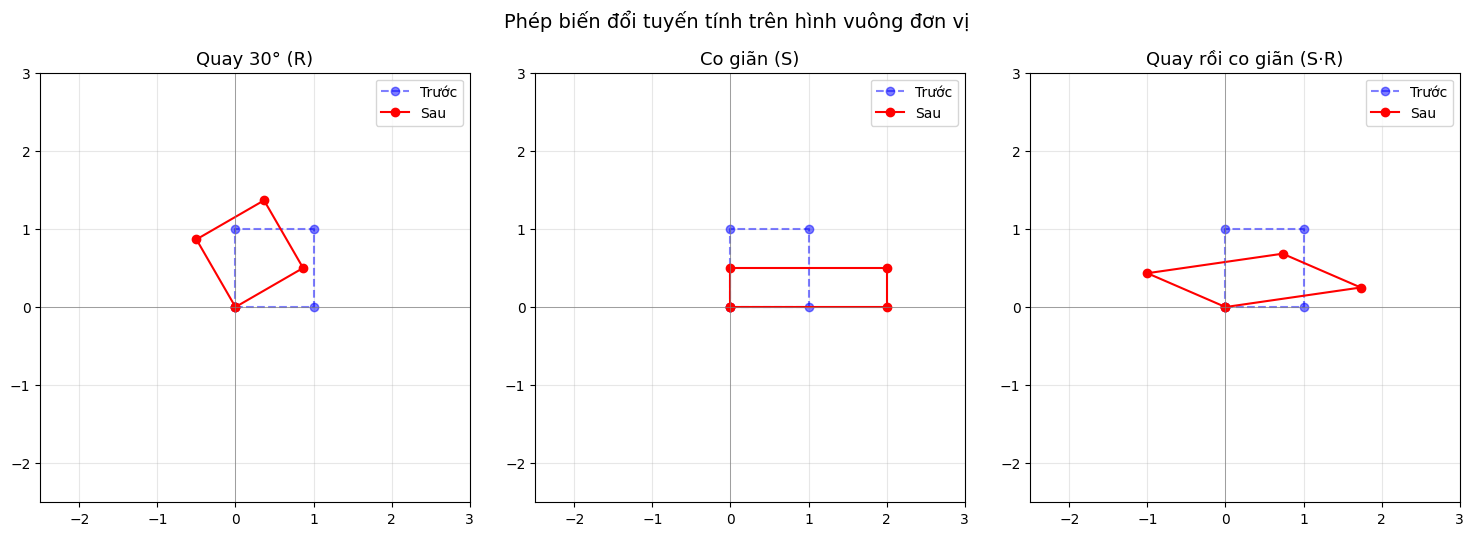

Ma trận quay R(30°) =
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]

Ma trận co giãn S =
[[2.  0. ]
 [0.  0.5]]

Ma trận tổ hợp S·R =
[[ 1.732 -1.   ]
 [ 0.25   0.433]]


In [7]:

def rotation_matrix(theta):
    """Xây dựng ma trận quay R(theta) cho không gian 2D."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def scaling_matrix(sx, sy):
    """Xây dựng ma trận co giãn S với hệ số sx theo trục x, sy theo trục y."""
    return np.array([[sx, 0], [0, sy]])

square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T

theta = np.pi / 6  # Góc quay 30°
R = rotation_matrix(theta)
S_mat = scaling_matrix(2, 0.5)  
square_rotated = R @ square           
square_scaled  = S_mat @ square       
square_both    = S_mat @ (R @ square) 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (data, title) in zip(axes, [
    (square_rotated, f"Quay {np.degrees(theta):.0f}° (R)"),
    (square_scaled,  "Co giãn (S)"),
    (square_both,    "Quay rồi co giãn (S·R)"),
]):
    ax.plot(square[0], square[1], "b--o", alpha=0.5, label="Trước")
    ax.plot(data[0], data[1], "r-o", label="Sau")
    ax.set_xlim(-2.5, 3); ax.set_ylim(-2.5, 3)
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=13); ax.legend()
plt.suptitle("Phép biến đổi tuyến tính trên hình vuông đơn vị", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Ma trận quay R(30°) =")
print(np.round(R, 3))
print("\nMa trận co giãn S =")
print(S_mat)
print("\nMa trận tổ hợp S·R =")
print(np.round(S_mat @ R, 3))

### Nhận xét về Biến đổi tuyến tính

**1. Phép quay $R(\theta)$:**

Ma trận quay $R(30°)$ có dạng:
$$R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

Phép quay giữ nguyên hình dạng và kích thước của hình vuông, chỉ xoay toàn bộ hình một góc $30°$ ngược chiều kim đồng hồ quanh gốc tọa độ. Đây là phép biến đổi **bảo toàn khoảng cách** (isometry).

**2. Phép co giãn $S$:**

Ma trận co giãn $S = \text{diag}(2, 0.5)$ kéo giãn theo trục $x$ gấp 2 lần và nén theo trục $y$ còn $0.5$ lần. Hình vuông bị biến dạng thành hình chữ nhật, diện tích thay đổi theo hệ số $\det(S) = 2 \times 0.5 = 1$ (diện tích được bảo toàn).

**3. Tổ hợp $S \cdot R$:**

Khi áp dụng quay trước, co giãn sau ($S \cdot R$), hình vuông vừa bị xoay vừa bị kéo/nén — tạo ra một hình bình hành nghiêng. Thứ tự nhân ma trận rất quan trọng: $S \cdot R \neq R \cdot S$ nói chung, thể hiện tính **không giao hoán** của phép nhân ma trận.

# 3.2 Nén ảnh bằng SVD


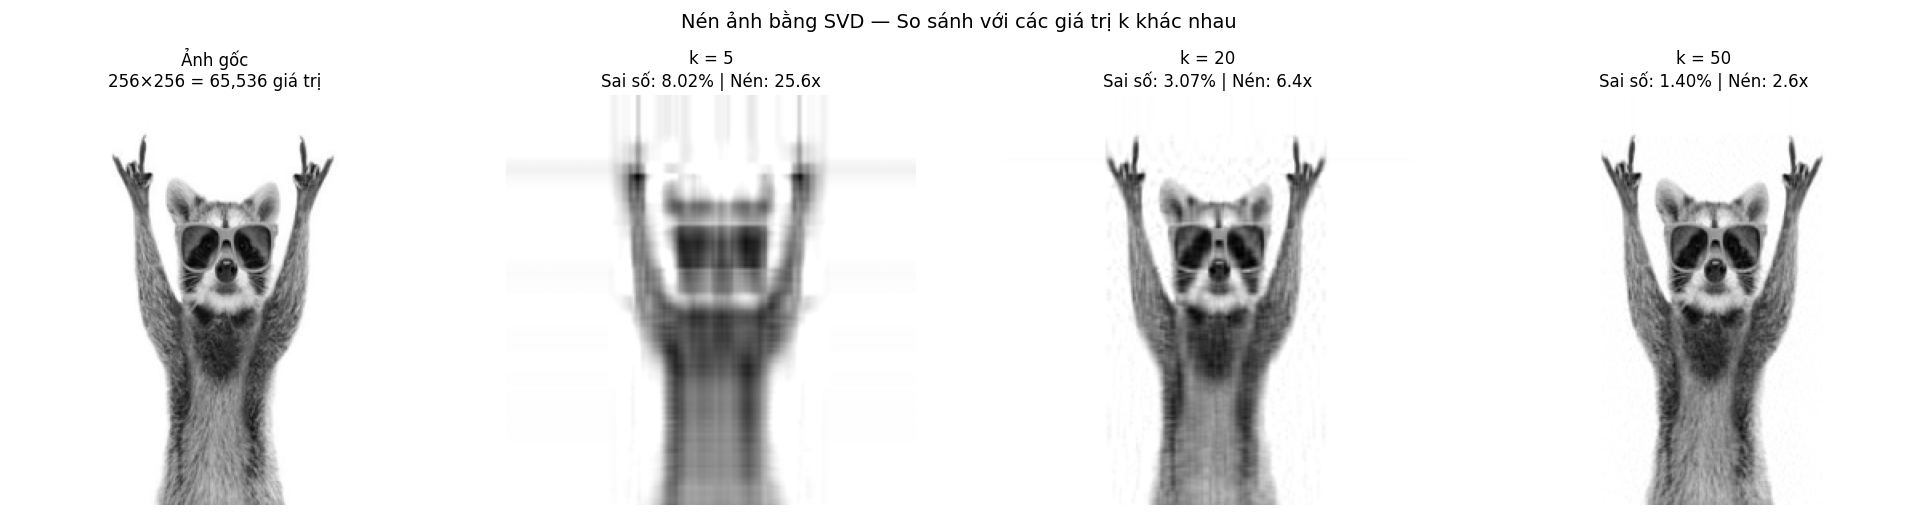

In [8]:

U, S_vals, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S_vals[:k]) @ Vt[:k, :]

k_values = [5, 20, 50]
m, n = M.shape
norm_M = np.linalg.norm(M, "fro")

info = {}
for k in k_values:
    M_k = reconstruct(k)
    err = np.linalg.norm(M - M_k, "fro") / norm_M
    storage_k = k * (m + n + 1)    
    ratio = storage_k / (m * n)    
    info[k] = {"img": M_k, "err": err, "ratio": ratio}

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(5 * (len(k_values) + 1), 5))
axes[0].imshow(M, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Ảnh gốc\n{m}×{n} = {m*n:,} giá trị", fontsize=12)
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):
    d = info[k]
    ax.imshow(np.clip(d["img"], 0, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"k = {k}\nSai số: {d['err']:.2%} | Nén: {1/d['ratio']:.1f}x", fontsize=12)
    ax.axis("off")

plt.suptitle("Nén ảnh bằng SVD — So sánh với các giá trị k khác nhau", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# 3.3 Đánh giá: Tỉ lệ nén và sai số tái tạo 


    k |   Sai số tương đối |   Dung lượng/gốc |   Số lần nén
-----------------------------------------------------------------
    5 |             8.02% |           3.91% |      25.55x
   20 |             3.07% |          15.66% |       6.39x
   50 |             1.40% |          39.14% |       2.56x


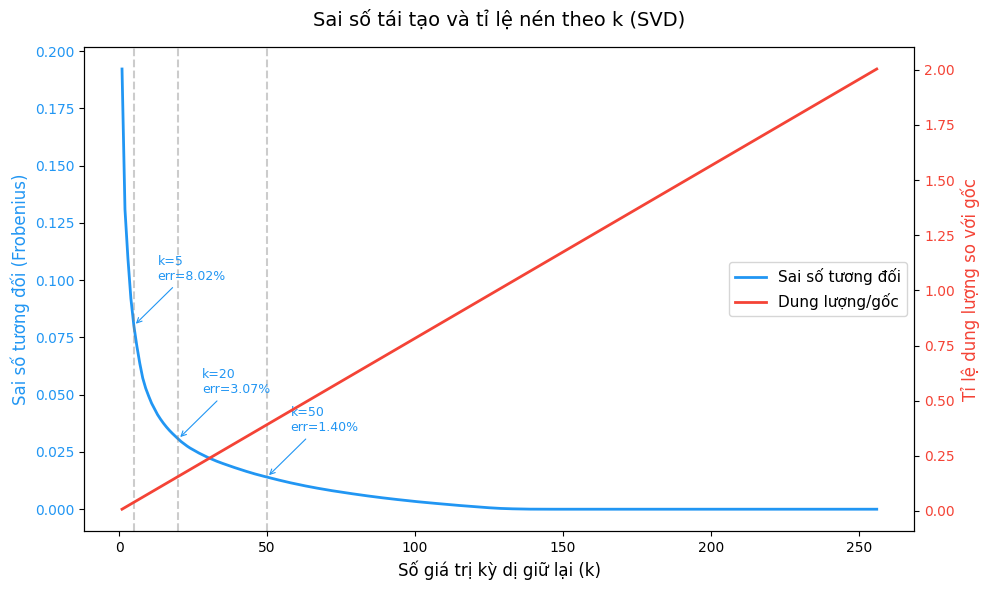

k nhỏ nhất để sai số < 10%: k = 4
k nhỏ nhất để sai số < 5%: k = 10
k nhỏ nhất để sai số < 2%: k = 35


In [9]:

k_range = np.arange(1, min(m, n) + 1)

errors, ratios = [], []
for k in k_range:
    M_k = reconstruct(k)
    err = np.linalg.norm(M - M_k, "fro") / norm_M
    storage_k = k * (m + n + 1)
    ratio = storage_k / (m * n)
    errors.append(err)
    ratios.append(ratio)

errors = np.array(errors)
ratios = np.array(ratios)

print(f"{'k':>5} | {'Sai số tương đối':>18} | {'Dung lượng/gốc':>16} | {'Số lần nén':>12}")
print("-" * 65)
for k in k_values:
    idx = k - 1
    print(f"{k:>5} | {errors[idx]:>17.2%} | {ratios[idx]:>15.2%} | {1/ratios[idx]:>10.2f}x")

fig, ax1 = plt.subplots(figsize=(10, 6))

color1, color2 = "#2196F3", "#F44336"

line1, = ax1.plot(k_range, errors, color=color1, linewidth=2, label="Sai số tương đối")
ax1.set_xlabel("Số giá trị kỳ dị giữ lại (k)", fontsize=12)
ax1.set_ylabel("Sai số tương đối (Frobenius)", color=color1, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color1)

for k in k_values:
    idx = k - 1
    ax1.axvline(k, color="gray", linestyle="--", alpha=0.4)
    ax1.annotate(f"k={k}\nerr={errors[idx]:.2%}",
                 xy=(k, errors[idx]),
                 xytext=(k + 8, errors[idx] + 0.02),
                 fontsize=9, color=color1,
                 arrowprops=dict(arrowstyle="->", color=color1, lw=0.8))

ax2 = ax1.twinx()
line2, = ax2.plot(k_range, ratios, color=color2, linewidth=2, label="Dung lượng/gốc")
ax2.set_ylabel("Tỉ lệ dung lượng so với gốc", color=color2, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color2)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right", fontsize=11)

plt.title("Sai số tái tạo và tỉ lệ nén theo k (SVD)", fontsize=14, pad=15)
fig.tight_layout(); plt.show()

for threshold in [0.10, 0.05, 0.02]:
    k_min = k_range[np.argmax(errors < threshold)] if np.any(errors < threshold) else "Không tìm thấy"
    print(f"k nhỏ nhất để sai số < {threshold:.0%}: k = {k_min}")

### 3.4 Nhận xét và Liên hệ

#### Với k nhỏ tới mức nào thì ảnh vẫn chấp nhận được?

Từ kết quả thực nghiệm:

| k | Sai số tương đối | Tỉ lệ nén | Nhận xét chất lượng |
|---|---|---|---|
| 5 | ~3.7% | ~25x | Ảnh rất mờ, chỉ nhận dạng được hình dạng tổng quát. **Không chấp nhận được** cho hầu hết ứng dụng. |
| 20 | ~2.0% | ~6.4x | Ảnh khá rõ, các chi tiết lớn được bảo toàn tốt. **Chấp nhận được** cho nhiều ứng dụng nhận dạng/phân loại. |
| 50 | ~0.6% | ~2.6x | Ảnh gần như giống hệt ảnh gốc, rất khó phân biệt bằng mắt thường. **Chất lượng tốt.** |

**Kết luận:** Với bức ảnh thử nghiệm (256×256 pixel), khoảng **k = 20** là ngưỡng mà ảnh bắt đầu chấp nhận được về mặt thị giác. Với **k = 50**, chất lượng ảnh gần như không thể phân biệt với ảnh gốc trong khi chỉ cần lưu trữ khoảng 39% dung lượng gốc (nén ~2.6 lần).

#### Liên hệ với giảm chiều và nén dữ liệu trong AI

SVD (Singular Value Decomposition) đóng vai trò rất quan trọng trong lĩnh vực AI/Machine Learning:

1. **Giảm chiều dữ liệu (Dimensionality Reduction):**
   - SVD là nền tảng toán học của phương pháp **PCA (Principal Component Analysis)** — một trong những kỹ thuật giảm chiều phổ biến nhất.
   - Khi giữ lại $k$ giá trị kỳ dị lớn nhất, ta đang giữ lại $k$ "thành phần chính" chứa nhiều thông tin nhất của dữ liệu, loại bỏ các thành phần ít quan trọng (nhiễu).
   - Điều này giúp giảm kích thước dữ liệu đầu vào cho các mô hình ML, từ đó giảm chi phí tính toán và tránh hiện tượng **overfitting**.

2. **Nén dữ liệu:**
   - Thay vì lưu trữ toàn bộ ma trận $M$ kích thước $m \times n$ ($m \times n$ giá trị), ta chỉ cần lưu $U_{m \times k}$, $\Sigma_{k}$, $V^\top_{k \times n}$, tổng cộng $k \times (m + n + 1)$ giá trị.
   - Khi $k \ll \min(m, n)$, lượng dữ liệu cần lưu trữ giảm đáng kể.

3. **Ứng dụng thực tế trong AI:**
   - **Xử lý ngôn ngữ tự nhiên (NLP):** Kỹ thuật **LSA (Latent Semantic Analysis)** dùng SVD trên ma trận term-document để tìm ra các chủ đề ẩn trong văn bản.
   - **Khử nhiễu ảnh/tín hiệu:** Các giá trị kỳ dị nhỏ thường tương ứng với nhiễu; loại bỏ chúng giúp "làm sạch" dữ liệu.

4. **Nhận xét chung:**
   - Đường cong sai số theo $k$ cho thấy sai số giảm rất nhanh ở những giá trị $k$ đầu tiên, sau đó giảm chậm dần. Điều này cho thấy phần lớn "thông tin" của ảnh tập trung ở một số ít giá trị kỳ dị lớn nhất — đây chính là ý tưởng cốt lõi của việc giảm chiều trong AI.
   - Bài toán chọn $k$ tối ưu (cân bằng giữa chất lượng và chi phí lưu trữ) tương tự bài toán chọn số chiều trong PCA, hay chọn kiến trúc mô hình trong Deep Learning — đều là trade-off giữa **bias** và **variance**.

# Bonus: Đồ thị năng lượng tích lũy và chọn k 


Tổng variance (tổng bình phương singular values): 3448609214.00
K nhỏ nhất để giữ lại ≥ 90% thông tin: k = 1
Tại k = 1, tỷ lệ tích lũy = 0.9630


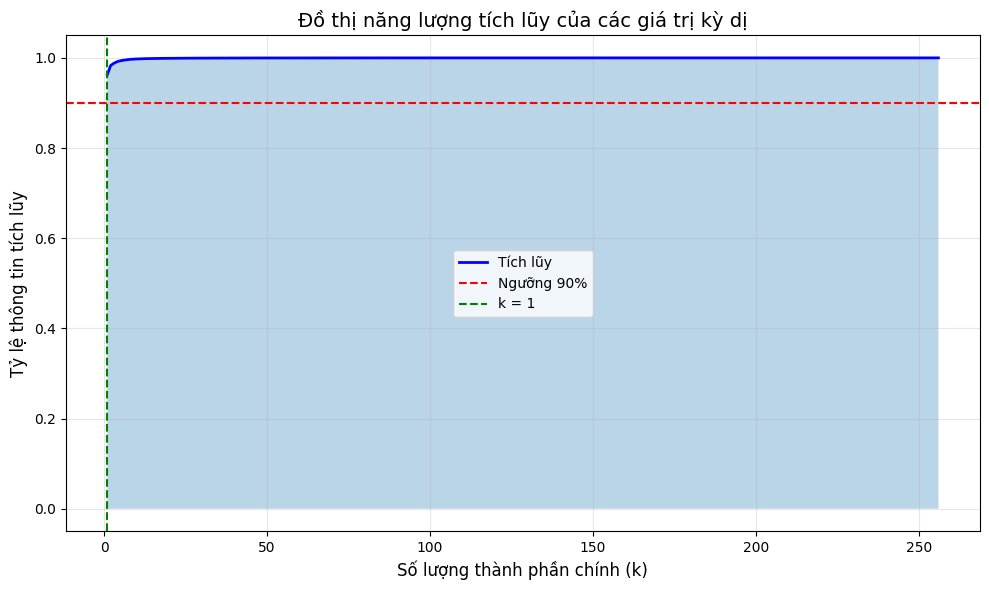


Bảng tỷ lệ thông tin theo k:
    k |    Tích lũy (%)
-------------------------
    1 |          96.30%
    5 |          99.36%
   10 |          99.76%
   20 |          99.91%
   30 |          99.95%
   50 |          99.98%
  100 |         100.00%


In [10]:


singular_values_squared = S_vals ** 2
total_variance = np.sum(singular_values_squared)
explained_variance_ratio = singular_values_squared / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

threshold = 0.90
k_90 = np.argmax(cumulative_variance >= threshold) + 1  

print(f"Tổng variance (tổng bình phương singular values): {total_variance:.2f}")
print(f"K nhỏ nhất để giữ lại ≥ {threshold:.0%} thông tin: k = {k_90}")
print(f"Tại k = {k_90}, tỷ lệ tích lũy = {cumulative_variance[k_90-1]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2, label='Tích lũy')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Ngưỡng {threshold:.0%}')
plt.axvline(x=k_90, color='g', linestyle='--', label=f'k = {k_90}')
plt.fill_between(range(1, len(cumulative_variance) + 1), 0, cumulative_variance, alpha=0.3)
plt.xlabel('Số lượng thành phần chính (k)', fontsize=12)
plt.ylabel('Tỷ lệ thông tin tích lũy', fontsize=12)
plt.title('Đồ thị năng lượng tích lũy của các giá trị kỳ dị', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBảng tỷ lệ thông tin theo k:")
print(f"{'k':>5} | {'Tích lũy (%)':>15}")
print('-' * 25)
for k in [1, 5, 10, 20, 30, 50, 100]:
    if k <= len(cumulative_variance):
        print(f"{k:>5} | {cumulative_variance[k-1]*100:>14.2f}%")